Setup complete. NumPy 2.1.3

1.
P(even) ~ 0.502  (true 0.5)
P(>4)   ~ 0.334  (true 0.333)
P(1) + P(2) = 0.334
P(1 or 2)   = 0.334  -> they match

excercise 1
1.1
P(both heads) = 0.252
1.2
P(at least one head) = 0.749
1.3
P(0) + P(1) + P(2) = 1.0

2.
P(6 | even) ~ 0.332  (true 1/3)
P(A)      = 0.498
P(A | B)  = 0.666
Independent? False

excercise-2
2.1
P(odd | <4) = 0.668
2.2
P(<4) = 0.499
2.3
P(odd) = 0.503
Independent? False

3.
P(sick | positive test) = 0.5
-> only ~50%, because the disease is rare (base-rate effect)
Simulated P(sick | positive) = 0.503

excercise-3
3.1
3.2
P(free) = 0.16
3.3
P(spam | free) = 0.75

4.
Bernoulli(0.3) mean ~ 0.288 (true 0.3)
Poisson(4) mean ~ 3.993 (true 4)


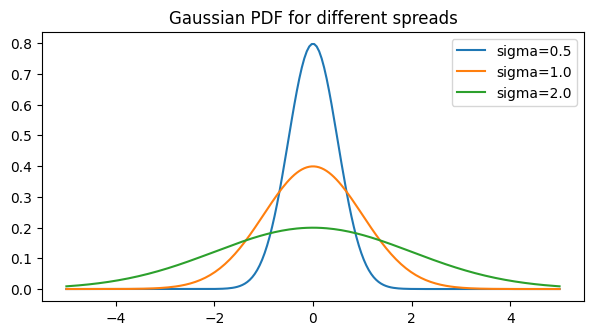


excercise 4
4.1
Poisson(2) mean ~ 2.006
4.2


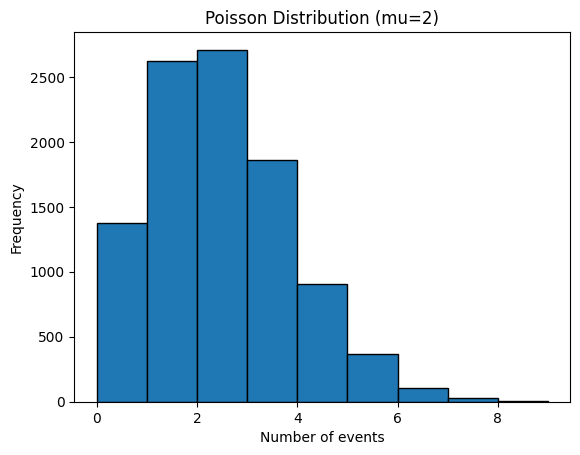

4.3


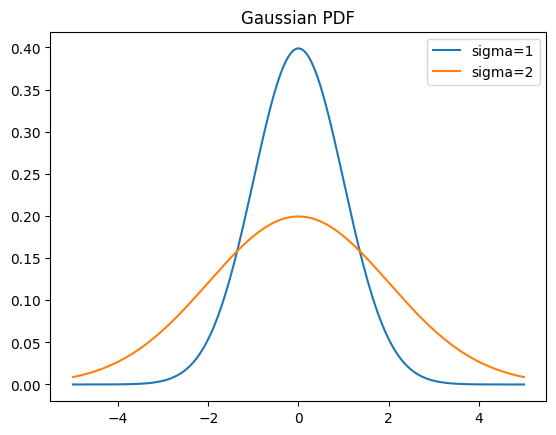


5.
Entropy fair coin   : 1.0 bits
Entropy biased coin : 0.469 bits
Entropy certain     : 0.0 bits
D(P || Q) = 0.737 bits
D(P || P) = 0.0 -> zero (identical)
Note: D(P||Q) != D(Q||P)  -> 0.531 (not symmetric)
0.990  petal length (cm)
0.975  petal width (cm)
0.474  sepal length (cm)
0.286  sepal width (cm)
-> higher MI = the feature tells us more about the class

excercise 5
5.1
Entropy 4-sided die = 2.0
Entropy 6-sided die = 2.585
5.2
D(P || Q) = 0.119 bits
5.3
Most informative: petal length (cm)
Least informative: sepal width (cm)


In [18]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
np.random.seed(42)
print('Setup complete. NumPy', np.__version__)

print("\n1.")
#1A. PROBABILITY BY SIMULATION
rolls = np.random.randint(1, 7, size=100_000)   # 100k dice rolls
p_even = (rolls % 2 == 0).mean()       # P(even)
p_gt4  = (rolls > 4).mean()            # P(roll > 4)
print('P(even) ~', round(p_even, 3), ' (true 0.5)')
print('P(>4)   ~', round(p_gt4, 3),  ' (true 0.333)')
#1B. THE ADDITION RULE (disjoint events)
p_1 = (rolls == 1).mean()
p_2 = (rolls == 2).mean()
p_1_or_2 = (np.isin(rolls, [1, 2])).mean()
print('P(1) + P(2) =', round(p_1 + p_2, 3))
print('P(1 or 2)   =', round(p_1_or_2, 3), ' -> they match')

# LAB EXERCISE 1 — Probability by simulation
print("\nexcercise 1")
flips = np.random.randint(0, 2, size=(100_000, 2))
heads = flips.sum(axis=1)
# 1. P(both heads)
print("1.1")
p_both = (heads == 2).mean()
print("P(both heads) =", round(p_both, 3))
# 2. P(at least one head)
print("1.2")
p_atleast = (heads >= 1).mean()
print("P(at least one head) =", round(p_atleast, 3))
# 3. P(0) + P(1) + P(2)
print("1.3")
p0 = (heads == 0).mean()
p1 = (heads == 1).mean()
p2 = (heads == 2).mean()
print("P(0) + P(1) + P(2) =", round(p0 + p1 + p2, 3))

print("\n2.")
#2A.Conditional probability & independence
rolls = np.random.randint(1, 7, size=100_000)
# P(roll is 6 | roll is even):  narrow the world to even rolls
even = rolls[rolls % 2 == 0]          # condition on 'even'
p_6_given_even = (even == 6).mean()
print('P(6 | even) ~', round(p_6_given_even, 3), ' (true 1/3)')
#2B.TESTING FOR INDEPENDENCE
A = rolls > 3
B = rolls % 2 == 0
p_A        = A.mean()
p_A_given_B = A[B].mean()
print('P(A)      =', round(p_A, 3))
print('P(A | B)  =', round(p_A_given_B, 3))
print('Independent?', np.isclose(p_A, p_A_given_B, atol=0.02))

#LAB EXERCISE 2 — Conditional probability
print("\nexcercise-2")
rolls = np.random.randint(1, 7, size=100_000)
# 1. P(odd | roll < 4)  -> condition on rolls < 4, then check odd
print("2.1")
# YOUR CODE HERE
less4 = rolls[rolls < 4]
p_odd_given_less4 = (less4 % 2 == 1).mean()
print("P(odd | <4) =", round(p_odd_given_less4, 3))
# 2. P(roll < 4)
print("2.2")
# YOUR CODE HERE
p_less4 = (rolls < 4).mean()
print("P(<4) =", round(p_less4, 3))
# 3. Compare P(odd | <4) with P(odd) overall — independent?
print("2.3")
# YOUR CODE HERE
p_odd = (rolls % 2 == 1).mean()
print("P(odd) =", round(p_odd, 3))
print("Independent?", np.isclose(p_odd_given_less4, p_odd, atol=0.02))

print("\n3.")
#3.Bayes' theorem
#3A. THE MEDICAL-TEST PROBLEM (by formula)
p_disease   = 0.01 # prior  P(D)
p_pos_given_D  = 0.99# true positive rate  P(+|D)
p_pos_given_nD = 0.01# false positive rate P(+|not D)
# P(+) = P(+|D)P(D) + P(+|notD)P(notD)   (total probability)
p_pos = p_pos_given_D * p_disease + p_pos_given_nD * (1 - p_disease)
# Bayes: P(D | +)
p_D_given_pos = (p_pos_given_D * p_disease) / p_pos
print('P(sick | positive test) =', round(p_D_given_pos, 3))
print('-> only ~50%, because the disease is rare (base-rate effect)')
#3B.THE SAME ANSWER BY SIMULATION (sanity check)
N = 1_000_000
has_disease = np.random.rand(N) < p_disease
# test result depends on disease status
tests_pos = np.where(has_disease,
                     np.random.rand(N) < p_pos_given_D,    # sick -> 99% positive
                     np.random.rand(N) < p_pos_given_nD)   # healthy -> 1% positive

among_positive = has_disease[tests_pos]
print('Simulated P(sick | positive) =', round(among_positive.mean(), 3))

#LAB EXERCISE 3 — A Bayes scenario (spam filter)
print("\nexcercise-3")
print("3.1")
# 1. priors / likelihoods
p_spam = 0.20
p_free_given_spam = 0.60
p_free_given_ham  = 0.05
print("3.2")
# 2. P('free') via total probability
# YOUR CODE HERE
p_free = p_free_given_spam * p_spam + p_free_given_ham * (1 - p_spam)
print("P(free) =", round(p_free, 3))
print("3.3")
# 3. Bayes: P(spam | 'free')
# YOUR CODE HERE
p_spam_given_free = (p_free_given_spam * p_spam) / p_free
print("P(spam | free) =", round(p_spam_given_free, 3))


print("\n4.")
#4.Probability distribution
#4A. BERNOULLI & POISSON (discrete)
# Bernoulli: a single yes/no trial with probability p
bern = stats.bernoulli(p=0.3).rvs(size=10_000)
print('Bernoulli(0.3) mean ~', round(bern.mean(), 3), '(true 0.3)')
# Poisson: count of events per interval, rate lambda
pois = stats.poisson(mu=4).rvs(size=10_000)
print('Poisson(4) mean ~', round(pois.mean(), 3), '(true 4)')
# 4B. THE GAUSSIAN (normal) — plot the bell curve
x = np.linspace(-5, 5, 200)
fig, ax = plt.subplots(figsize=(7, 3.5))
for sigma in [0.5, 1.0, 2.0]:
    ax.plot(x, stats.norm(0, sigma).pdf(x), label=f'sigma={sigma}')
ax.set_title('Gaussian PDF for different spreads'); ax.legend(); plt.show()
#LAB EXERCISE 4 — Simulate & plot distributions
print("\nexcercise 4")
# 1. Poisson(mu=2) samples + mean
# YOUR CODE HERE
print("4.1")
pois = stats.poisson(mu=2).rvs(size=10_000)
print("Poisson(2) mean ~", round(pois.mean(), 3))
print("4.2")
# 2. histogram of the samples  (plt.hist(...))
# YOUR CODE HERE
plt.hist(pois, bins=range(0, 10), edgecolor='black')
plt.title("Poisson Distribution (mu=2)")
plt.xlabel("Number of events")
plt.ylabel("Frequency")
plt.show()
print("4.3")
# 3. Gaussian PDF for two sigmas on one plot
# YOUR CODE HERE
x = np.linspace(-5, 5, 200)
for sigma in [1, 2]:
    plt.plot(x, stats.norm(0, sigma).pdf(x), label=f"sigma={sigma}")
plt.title("Gaussian PDF")
plt.legend()
plt.show()


print("\n5.")
#5.Entropy, KL divergence & mutual information
#5A. ENTROPY — how uncertain is a distribution?
from scipy.stats import entropy
fair   = [0.5, 0.5]      # a fair coin: maximum uncertainty
biased = [0.9, 0.1]      # a biased coin: more predictable
certain= [1.0, 0.0]      # no uncertainty at all
# base=2 gives entropy in BITS
print('Entropy fair coin   :', round(entropy(fair, base=2), 3), 'bits')
print('Entropy biased coin :', round(entropy(biased, base=2), 3), 'bits')
print('Entropy certain     :', round(entropy(certain, base=2), 3), 'bits')
#5B. KL DIVERGENCE — how far is Q from P?
P = np.array([0.5, 0.5])
Q = np.array([0.9, 0.1])
# scipy's entropy(P, Q) computes the KL divergence D(P || Q)
print('D(P || Q) =', round(entropy(P, Q, base=2), 3), 'bits')
print('D(P || P) =', round(entropy(P, P, base=2), 3), '-> zero (identical)')
print('Note: D(P||Q) != D(Q||P)  ->', round(entropy(Q, P, base=2), 3), '(not symmetric)')
#5C. MUTUAL INFORMATION — which feature is most informative?
from sklearn.feature_selection import mutual_info_classif
from sklearn.datasets import load_iris
iris = load_iris()
mi = mutual_info_classif(iris.data, iris.target, random_state=0)
for name, score in sorted(zip(iris.feature_names, mi), key=lambda t: -t[1]):
    print(f'{score:.3f}  {name}')
print('-> higher MI = the feature tells us more about the class')

#LAB EXERCISE 5 — Information theory
print("\nexcercise 5")
# 1. Entropy of a fair 4-sided and 6-sided die (use base=2)
# hint: a fair n-sided die is [1/n]*n
# YOUR CODE HERE
print("5.1")
print("Entropy 4-sided die =", round(entropy([1/4]*4, base=2), 3))
print("Entropy 6-sided die =", round(entropy([1/6]*6, base=2), 3))
# 2. KL divergence D(P || Q)
P = np.array([0.7, 0.3]); Q = np.array([0.5, 0.5])
# YOUR CODE HERE
print("5.2")
P = np.array([0.7, 0.3])
Q = np.array([0.5, 0.5])
print("D(P || Q) =", round(entropy(P, Q, base=2), 3), "bits")
# 3. Most / least informative iris feature (from 5C)
# Most informative: ...   Least informative: ...
print("5.3")
mi = mutual_info_classif(iris.data, iris.target, random_state=0)
print("Most informative:", iris.feature_names[np.argmax(mi)])
print("Least informative:", iris.feature_names[np.argmin(mi)])


